In [9]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_json('../../data/raw/training/EXIST2026_training.json')
df = df.T
df.head()

,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
110887,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,memes/110887.jpeg,6,"[Annotator_193, Annotator_194, Annotator_195, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Multiracial, White or Cau...","[High school degree or equivalent, Master’s de...","[Sweden, United States, Spain, Portugal, Spain...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, DIRECT, DIRECT, DIRECT, DIRECT, ...","[[IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [M...",TRAIN-MEME_ES
110466,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,memes/110466.jpeg,6,"[Annotator_103, Annotator_104, Annotator_105, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, Hispa...","[Bachelor’s degree, High school degree or equi...","[Spain, Portugal, Spain, Canada, United States...","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, NO, YES, YES, NO, NO]","[DIRECT, -, DIRECT, DIRECT, -, -]","[[STEREOTYPING-DOMINANCE], [-], [STEREOTYPING-...",TRAIN-MEME_ES
111269,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,memes/111269.jpeg,6,"[Annotator_277, Annotator_278, Annotator_279, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, other,...","[Bachelor’s degree, Master’s degree, High scho...","[Spain, Spain, Spain, Italy, Spain, Portugal]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities':...","[YES, YES, YES, YES, YES, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, -]","[[OBJECTIFICATION, SEXUAL-VIOLENCE], [OBJECTIF...",TRAIN-MEME_ES
110593,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,memes/110593.jpeg,6,"[Annotator_127, Annotator_128, Annotator_129, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Master’s de...","[Poland, Portugal, Spain, United Kingdom, Mexi...","{'users': ['ES1', 'ES3'], 'modalities': {'ET':...","[NO, YES, NO, NO, NO, NO]","[-, JUDGEMENTAL, -, -, -, -]","[[-], [STEREOTYPING-DOMINANCE, OBJECTIFICATION...",TRAIN-MEME_ES
110946,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,memes/110946.jpeg,6,"[Annotator_211, Annotator_212, Annotator_213, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, Bachelo...","[Portugal, Chile, Italy, Portugal, Spain, Chile]","{'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modal...","[YES, YES, YES, YES, NO, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, -, -]","[[OBJECTIFICATION], [SEXUAL-VIOLENCE], [OBJECT...",TRAIN-MEME_ES


In [6]:
df.number_annotators.value_counts()

number_annotators
6    3984
Name: count, dtype: int64

In [7]:
rows = []
for _, row in df.iterrows():
    for ann, lab in zip(row["annotators"], row["labels_task2_1"]):
        rows.append({
            "item_id": row["id_EXIST"],
            "annotator_id": ann,
            "label": 1 if lab.lower() == "yes" else 0
        })
ann_df = pd.DataFrame(rows)

In [22]:

rows = []

for _, row in df.iterrows():
    annotators = row["annotators"]

    # demographic lists (aligned with annotators)
    sexes = row["gender_annotators"]
    ages = row["age_annotators"]
    races = row["ethnicities_annotators"]
    study = row["study_levels_annotators"]
    country = row["countries_annotators"]

    for ann, s, a, r, st, c in zip(annotators, sexes, ages, races, study, country):
        rows.append({
            "annotator_id": ann,
            "sex": s,
            "age": a,
            "race": r,
            "study": st,
            "country": c
        })

annotator_info = pd.DataFrame(rows)

In [24]:
annotator_info.head()
print(annotator_info.shape)

(23904, 6)


In [25]:
cols = ["sex", "age", "race"]

inconsistent = (
    annotator_info
    .groupby("annotator_id")[cols]
    .nunique()
)

# annotators where ANY column has more than 1 unique value
bad_ids = inconsistent[(inconsistent > 1).any(axis=1)]

print(bad_ids)

Empty DataFrame
Columns: [sex, age, race]
Index: []


In [26]:
annotator_info = annotator_info.drop_duplicates(subset="annotator_id")


In [27]:
print(annotator_info.shape)

(887, 6)


In [28]:
ann_df = ann_df.merge(
    annotator_info,
    on="annotator_id",
    how="left"
)

In [30]:
ann_df.head()
print(ann_df.shape)

(23904, 8)


In [31]:
annotator_stats = ann_df.groupby("annotator_id").agg(
    yes_rate=("label", "mean"),
    n=("label", "count")
).reset_index()

annotator_stats = annotator_stats.merge(
    annotator_info,
    on="annotator_id",
    how="left"
)

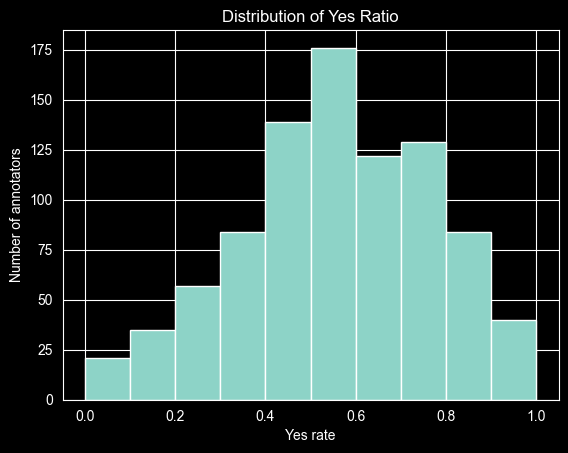

In [39]:
plt.hist(annotator_stats["yes_rate"].dropna(), bins=10)
plt.xlabel("Yes rate")
plt.ylabel("Number of annotators")
plt.title("Distribution of Yes Ratio")
plt.show()

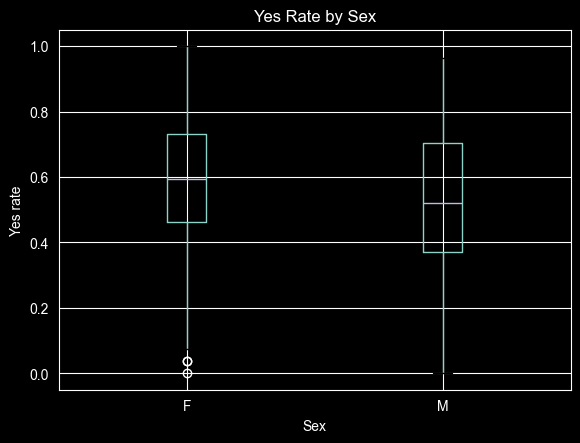

In [41]:
annotator_stats.boxplot(column="yes_rate", by="sex")
plt.title("Yes Rate by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("Yes rate")
plt.show()

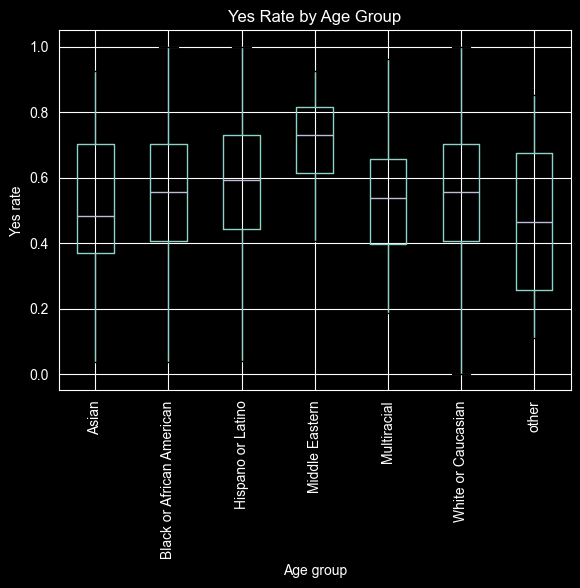

In [65]:
annotator_stats.boxplot(column="yes_rate", by="race")
plt.title("Yes Rate by Ethnicity Group")
plt.suptitle("")
plt.xlabel("Ethnicity group")
plt.ylabel("Yes rate")
plt.xticks(rotation=90)
plt.show()

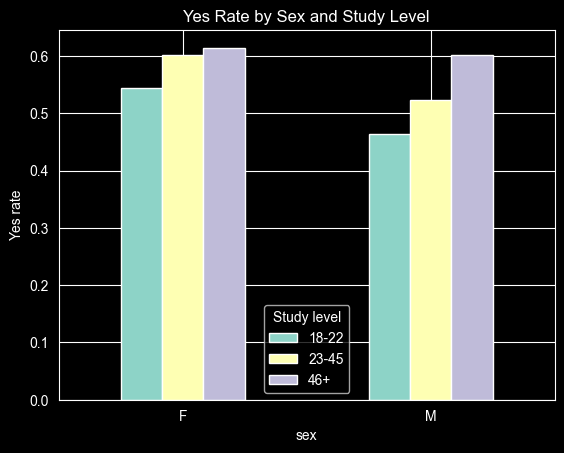

In [53]:
grouped = annotator_stats.groupby(["sex", "age"])["yes_rate"].mean().unstack()

grouped.plot(kind="bar")

plt.ylabel("Yes rate")
plt.title("Yes Rate by Sex and Study Level")
plt.xticks(rotation=0)
plt.legend(title="Study level")
plt.show()

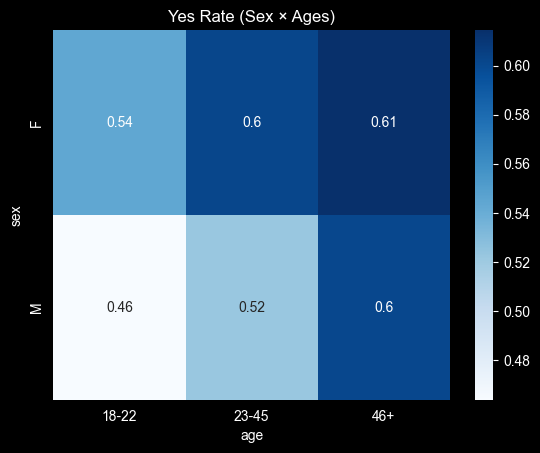

In [60]:
pivot = annotator_stats.pivot_table(
    values="yes_rate",
    index="sex",
    columns="age",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Blues")
plt.title("Yes Rate (Sex × Ages)")
plt.show()